<a href="https://colab.research.google.com/github/roseal3tb/IT326/blob/main/final_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Analysis**

# 1- Problem

Heart disease remains a critical global health issue, responsible for a significant number of deaths each year. One of the main difficulties is that many individuals remain unaware of their condition until serious complications arise, as routine medical check-ups often miss early warning signs. This highlights the urgent need for more effective early detection strategies.

The core objective of this project is to develop a data driven approach capable of identifying individuals at high risk of heart disease. By examining key health indicators such as age, blood pressure, cholesterol, and fasting blood sugar.
we aim to construct a predictive model that can classify a person's likelihood of developing heart disease. Such a tool would empower healthcare professionals to intervene early, recommend lifestyle changes, or initiate medical treatment before the disease progresses to a critical stage.

Addressing this problem is of great importance. Early detection not only saves lives but also reduces healthcare costs, limits hospital admissions, and enhances overall public health outcomes. Leveraging data analysis and machine learning to tackle heart disease risk is a meaningful step toward building a healthier, more sustainable society.

# 2- Data Mining Task

This study applies two essential data mining approaches, classification and clustering, to evaluate the risk of heart disease. The classification technique builds a predictive model to determine whether a patient is likely to have heart disease based on medical attributes such as age, sex, blood pressure, cholesterol, chest pain type, and other health indicators. The model classifies patients into two categories: with heart disease or without.

Clustering is used to group patients based on similarities in their health characteristics without using the heart disease label. This unsupervised approach reveals hidden patterns, patient subgroups, and underlying risk profiles. Combining both methods provides a deeper understanding of patient patterns and enhances the identification of risk factors associated with heart disease.

# 3- Data

The dataset used in this project was obtained from Kaggle and contains medical information for 918 patients across 12 attributes, including demographic factors (Age, Sex), clinical measurements (RestingBP, Cholesterol, MaxHR, Oldpeak), and categorical indicators (ChestPainType, RestingECG, ExerciseAngina, ST_Slope). The target variable, HeartDisease, is binary with 508 positive cases and 410 negative cases, making it suitable for predictive modeling.

Phase 1 explored the raw dataset through descriptive statistics, distribution plots, outlier detection, and class analysis, revealing issues such as missing values (represented as zeros) and significant outliers in features like Cholesterol and RestingBP.

Phase 2 focused on cleaning and preparing the data by replacing missing entries, removing noise, capping outliers using the IQR method, encoding categorical variables, normalizing numerical attributes, and discretizing Age and Oldpeak into groups. This preprocessing ensured data consistency and improved model readiness. Overall, the dataset is highly suitable for both classification and clustering techniques for heart disease prediction.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectKBest, f_classif
import pickle

df = pd.read_csv('/content/sample_data/heart.csv')

data = pd.read_csv('/content/sample_data/heart.csv')
num_attributes = data.shape[1]
num_object = data.shape[0]
attribute_types = data.dtypes.to_frame( name = 'Data Types')
class_name = data.columns[-1]
class_label = data.columns[-1]

print(f"\033[1mGeneral iformation:\n")
print(f"\033[1mNumber of attributes:\033[0m {num_attributes}\n")
print(f"\033[1mNumber of objects:\033[0m {num_object}\n")
print(f"\033[1mClass lable:\033[0m {class_label}\n")
print(f"\033[1mAttribute types:\033[0m")
print(attribute_types)
import seaborn as sns
import matplotlib.pyplot as plt

# Load the original dataset (before preprocessing)
df = pd.read_csv("/content/sample_data/heart.csv")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,4)

# 1) Show first few rows of the dataset
print("Dataset Preview:")
display(df.head())

# 2) Structure of dataset: rows, columns, types
print("\nDataset Info:")
print(df.info())

General iformation:

Number of attributes: 12

Number of objects: 918

Class lable: HeartDisease

Attribute types:
               Data Types
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
Dataset Preview:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


# 4- Data Preprocessing

To prepare the dataset for effective modeling, several preprocessing steps were applied based on issues identified in Phase 2. First, missing values, primarily in Cholesterol and RestingBP, were replaced with the column mean. Outliers in numerical features (RestingBP, Cholesterol, MaxHR, Oldpeak) were detected using the IQR method and capped to reduce skewness. No duplicate rows were found. Categorical attributes (Sex, ChestPainType, RestingECG, ST_Slope, ExerciseAngina) were label-encoded into numerical values. Numerical variables (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) were standardized using z-score normalization. Noise was reduced by replacing unrealistic zero values in RestingBP and Cholesterol with the median of valid entries. Finally, Age and Oldpeak were discretized into meaningful categorical groups (e.g., Young/Middle/Old) to improve interpretability. These preprocessing steps ensured the dataset was clean, consistent, and ready for classification and clustering analysis.

Preprocessed data successfully generated and saved to /content/sample_data/Preprocessed_data.csv

Data After Preprocessing:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,2,1,1,0.462639,1.060551,0,1,1.384080,0,2,2,0
1,0,0,2,1.644173,-1.359233,0,1,0.754610,0,0,1,1
2,2,1,1,-0.128128,0.927352,0,2,-1.527219,0,2,2,0
3,0,0,0,0.344485,-0.604438,0,1,-1.133801,1,0,1,1
4,0,1,2,1.053406,-1.026235,0,1,-0.583014,0,2,2,0



Summary Statistics:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,9.180000e+02,9.180000e+02,918.000000,918.000000,9.180000e+02,918.000000,918.000000,918.000000,918.000000
mean,0.443355,0.789760,0.781046,-6.346896e-16,-5.418082e-17,0.233115,0.989107,-2.322035e-16,0.404139,1.132898,1.361656,0.553377
std,0.670743,0.407701,0.956519,1.000545e+00,1.000545e+00,0.423046,0.631671,1.000545e+00,0.490992,0.929222,0.607056,0.497414
min,0.000000,0.000000,0.000000,-2.491197e+00,-2.369327e+00,0.000000,0.000000,-2.786160e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,-7.188954e-01,-6.044382e-01,0.000000,1.000000,-6.616980e-01,0.000000,0.000000,1.000000,0.000000
50%,0.000000,1.000000,0.000000,-1.281283e-01,-9.384154e-02,0.000000,1.000000,4.645600e-02,0.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,2.000000,4.626389e-01,5.721541e-01,0.000000,1.000000,7.546100e-01,1.000000,2.000000,2.000000,1.000000
max,2.000000,1.000000,3.000000,2.234940e+00,2.337043e+00,1.000000,2.000000,2.564337e+00,1.000000,3.000000,2.000000,1.000000


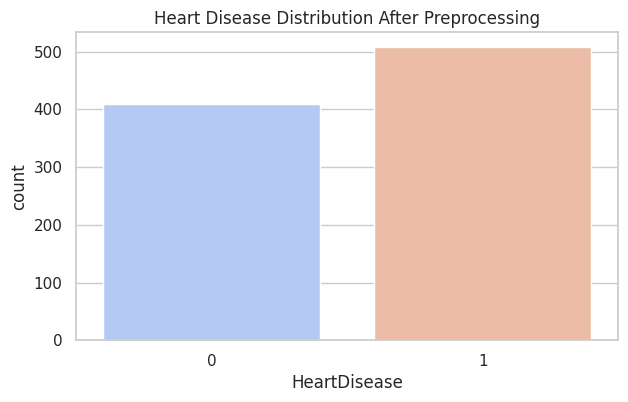

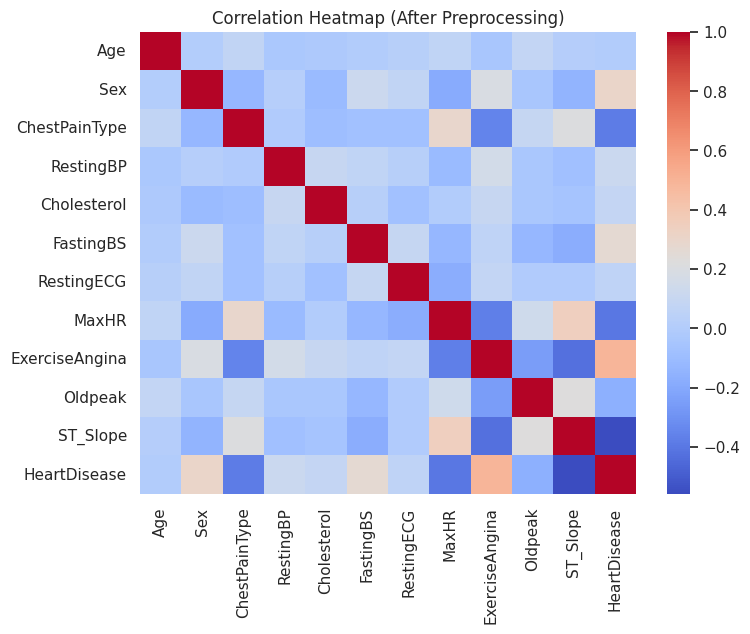

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the original dataset
df = pd.read_csv("/content/sample_data/heart.csv")

# --- Preprocessing steps as described in YbsQo3L3FRr_ ---

# 1. Replace unrealistic zero values in RestingBP and Cholesterol with the median of valid entries
# Assuming 0 is an unrealistic value for these features
for col in ['RestingBP', 'Cholesterol']:
    df[col] = df[col].replace(0, np.nan) # Replace 0 with NaN first
    df[col] = df[col].fillna(df[col].median()) # Then fill NaNs with median

# 2. Outlier capping using the IQR method for numerical features
numerical_cols_for_outliers = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# --- NEW: Discretize Age and Oldpeak before scaling/label encoding ---
# Discretize Age based on common age groups (original age values)
bins_age = [df['Age'].min() - 1, 40, 60, df['Age'].max() + 1] # Adjust max to be inclusive
labels_age = ['Young', 'Middle', 'Old']
df['Age'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, right=True, include_lowest=True)

# Discretize Oldpeak into categorical groups (original Oldpeak values)
# Assuming values like 0 (Normal), >0 to 1.5 (Mild), >1.5 to 3.0 (Moderate), >3.0 (Old/Severe)
bins_oldpeak = [df['Oldpeak'].min() - 0.1, 0.05, 1.5, 3.0, df['Oldpeak'].max() + 1] # Adjust based on data distribution
labels_oldpeak = ['Normal', 'Mild', 'Moderate', 'Old']
df['Oldpeak'] = pd.cut(df['Oldpeak'], bins=bins_oldpeak, labels=labels_oldpeak, right=True, include_lowest=True)

# Update categorical_cols and numerical_cols_for_scaling based on the above discretization
categorical_cols_updated = ['Sex', 'ChestPainType', 'RestingECG', 'ST_Slope', 'ExerciseAngina', 'Age', 'Oldpeak']
# numerical_cols_for_scaling should now exclude 'Age' and 'Oldpeak'
numerical_cols_for_scaling_updated = ['RestingBP', 'Cholesterol', 'MaxHR']

# 3. Label encoding for all categorical attributes (using updated list)
label_encoder = LabelEncoder()
for col in categorical_cols_updated:
    # Convert to string before encoding to handle potential NaNs from pd.cut gracefully
    df[col] = df[col].astype(str)
    df[col] = label_encoder.fit_transform(df[col])

# 4. Z-score normalization for numerical variables (using updated list)
scaler = StandardScaler() # Using StandardScaler for z-score normalization
df[numerical_cols_for_scaling_updated] = scaler.fit_transform(df[numerical_cols_for_scaling_updated])

# 5. Save the preprocessed DataFrame
output_path = '/content/sample_data/Preprocessed_data.csv'
df.to_csv(output_path, index=False)
print(f"Preprocessed data successfully generated and saved to {output_path}")

# --- Original display and plotting from HicWi4w0FV-5 (now using the preprocessed df) ---
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,4)

print("\nData After Preprocessing:")
display(df.head())

print("\nSummary Statistics:")
display(df.describe())

plt.figure()
sns.countplot(x="HeartDisease", data=df, hue="HeartDisease", palette="coolwarm", legend=False)
plt.title("Heart Disease Distribution After Preprocessing")
plt.show()

plt.figure(figsize=(8,6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (After Preprocessing)")
plt.show()

# 5- Data Mining Technique

In this project, our group will apply two main data mining techniques: classification and clustering, using Python and standard machine-learning libraries. For classification, we will use a Decision Tree Classifier from sklearn.tree to predict heart disease risk based on attributes such as age, blood pressure, cholesterol, and gender. Decision trees are chosen for their interpretability, ability to handle mixed data types, and effectiveness with medical datasets. Model performance will be evaluated using accuracy, precision, recall, and a confusion matrix visualized with ConfusionMatrixDisplay from sklearn.metrics.

For clustering, we will apply K-Means from sklearn.cluster to group patients based on similarities in health-related features, independent of heart disease diagnosis. This unsupervised approach helps reveal hidden patterns and identify patient subgroups with similar health profiles. Throughout the process, Pandas, NumPy, Matplotlib, and Seaborn will be used for data preprocessing, statistical analysis, and visualization.


# 6- Evaluation and Comparison

**Classification - Evaluation and Comparison**

This section presents a comprehensive evaluation of the classification techniques applied to the Heart Disease dataset. Two decision tree classifiers were developed using Entropy (Information Gain) and Gini Index as attribute selection measures. To ensure fair comparison, each classifier was trained and tested under three train/test partitions: 70/30, 60/40, and 80/20.

**Evaluation of the Classification Models**

The results across all splits show that both models achieve stable classification outcomes. Sensitivity ranges from 74.88% to 81.82%, indicating good identification of heart disease cases. Specificity ranges from 75.22% to 81.08%, reflecting strong ability to correctly classify non-disease patients. Precision remains high between 82.56% and 86.27%, demonstrating accurate positive predictions. Overall, both splitting criteria deliver consistent performance with no clear advantage toward either class.

**Accuracy Comparison of the Classification Algorithms**


Table 1. Accuracy of Entropy and Gini Decision Tree Models

| **Train/Test Split** | **Information Gain Accuracy** | **Gini Accuracy** | **Best Algorithm**   |
| -------------------- | ----------------------------- | ----------------- | -------------------- |
| **70% / 30%**        | 76.45%                        | **77.89%**        | **Gini**             |
| **60% / 40%**        | **77.44%**                    | 76.08%            | **Information Gain** |
| **80% / 20%**        | **80.98%**                    | 80.43%            | **Information Gain** |


Based on the results in Table 1, Information Gain provides the highest accuracy and sensitivity, while Gini achieves better specificity and precision. Therefore, the best algorithm depends on the goal: Information Gain for detecting more true cases, and Gini for reducing false positives.

**confusion matrix.**

**Information Gain (Entropy):**

**Splitting Data into: 70% Training and 30% Test**

[[ 88  21]
 [ 42 125]]


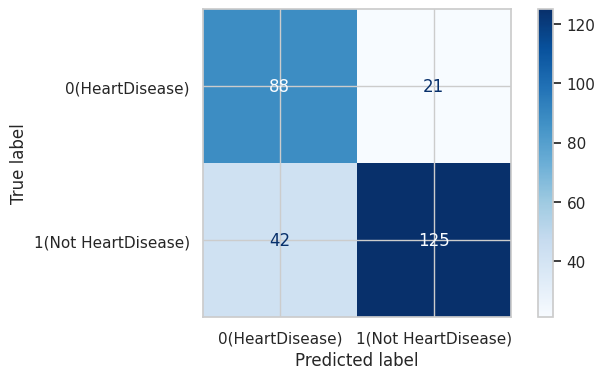

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

# Initialize the Decision Tree Classifier using entropy as criterion
classifier = DecisionTreeClassifier(criterion='entropy', random_state=1)

# Fit the classifier to the training data
classifier.fit(X_train, y_train)

# Predict labels for the test dataset
y_pred = classifier.predict(X_test)


# Compute the confusion matrix and print it
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Define custom class labels for display
class_labels = {0: '0(HeartDisease)', 1: '1(Not HeartDisease)'}

# Create the ConfusionMatrixDisplay with the custom labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[class_labels[0], class_labels[1]])

# Plot the confusion matrix using the 'Blues' colormap
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model correctly identified 88 patients with HeartDisease and 125 patients without HeartDisease.

However, it misclassified 21 HeartDisease patients as healthy and incorrectly predicted 42 healthy patients as having HeartDisease.

**Splitting Data into: 60% Training and 40% Test**


Confusion Matrix:
 [[119  34]
 [ 41 174]]


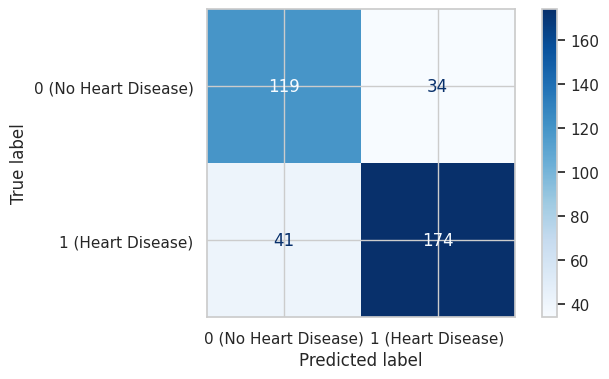

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the preprocessed data
df = pd.read_csv('/content/sample_data/Preprocessed_data.csv')

# Remove the target column from features
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split the data: 60% training and 40% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1
)

# Initialize and train classifier
clf3 = DecisionTreeClassifier(criterion='entropy', random_state=1)
clf3.fit(X_train, y_train)  # Should work now

# Predict and evaluate
y_pred = clf3.predict(X_test)
cm3 = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm3)

# Plot confusion matrix
class_labels = ['0 (No Heart Disease)', '1 (Heart Disease)']
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model correctly identified 119 patients with HeartDisease and 174 patients without HeartDisease.

However, it misclassified 21 HeartDisease patients as healthy and incorrectly predicted 41 healthy patients as having HeartDisease.

**Splitting Data into: 80% Training and 20% Test**

[[59 15]
 [19 91]]


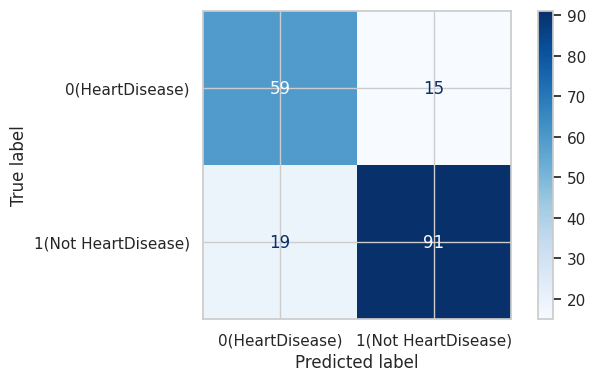

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


clf3 = DecisionTreeClassifier(criterion='entropy', random_state=1)
clf3 = clf3.fit(X_train, y_train)


y_pred = clf3.predict(X_test)
cm3 = confusion_matrix(y_test, y_pred)
print(cm3)

cm3 = confusion_matrix(y_test, y_pred)

class_labels = {0: '0(HeartDisease)', 1: '1(Not HeartDisease)'}


disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=[class_labels[0], class_labels[1]])
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model correctly identified 59 patients with HeartDisease and 91 patients without HeartDisease.

However, it misclassified 15 HeartDisease patients as healthy and incorrectly predicted 19 healthy patients as having HeartDisease.

**Gini Index:**

**Splitting Data into: 70% Training and 30% Test**

[[ 91  18]
 [ 44 123]]


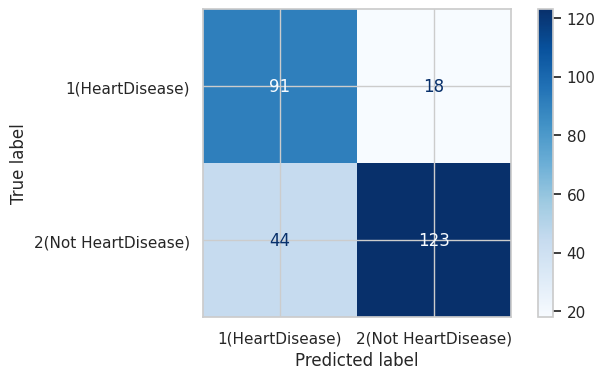

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf4 = DecisionTreeClassifier(criterion='gini',random_state=1)

clf4 = clf4. fit (X_train, y_train)

y_pred = clf4.predict (X_test)

# Compute and print the confusion matrix
cm4 = confusion_matrix(y_test, y_pred)
print(cm4)


# Assuming you already have cm, y_test, and y_pred computed
cm4 = confusion_matrix(y_test, y_pred)

class_labels = {1: '1(HeartDisease)', 2: '2(Not HeartDisease)'}
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=[class_labels[1], class_labels[2]])
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model correctly identified 91 patients with HeartDisease and 123 patients without HeartDisease.

However, it misclassified 18 HeartDisease patients as healthy and incorrectly predicted 44 healthy patients as having HeartDisease.

**Splitting Data into: 60% Training and 40% Test**

[[128  25]
 [ 51 164]]


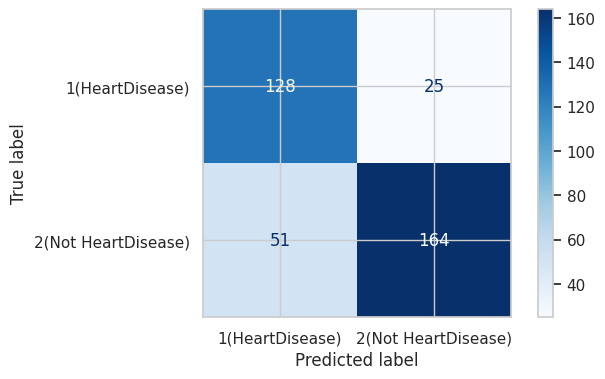

In [22]:

# Split data into 60% training and 40% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

clf = DecisionTreeClassifier(criterion='gini', random_state=1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Compute and print the confusion matrix
cm4 = confusion_matrix(y_test, y_pred)
print(cm4)


# Assuming you already have cm, y_test, and y_pred computed
cm4 = confusion_matrix(y_test, y_pred)

class_labels = {1: '1(HeartDisease)', 2: '2(Not HeartDisease)'}
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=[class_labels[1], class_labels[2]])
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model accurately identified 128 true HeartDisease cases and 164 true non-HeartDisease cases.

However, it misclassified 25 HeartDisease patients as healthy, and it also incorrectly labeled 51 healthy individuals as having HeartDisease.

**Splitting Data into: 80% Training and 20% Test**

[[61 13]
 [26 84]]


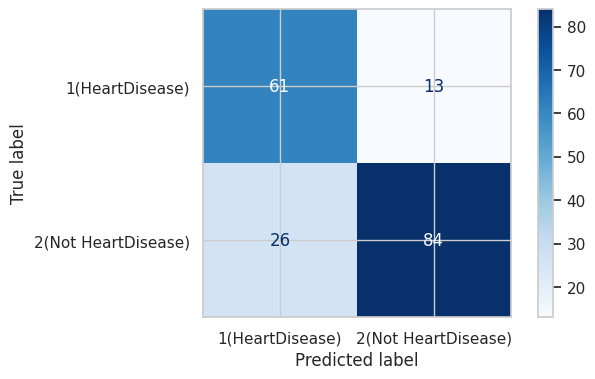

In [23]:
#Split the data (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

clf = DecisionTreeClassifier(criterion='gini', random_state=1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Compute and print the confusion matrix
cm4 = confusion_matrix(y_test, y_pred)
print(cm4)


# Assuming you already have cm, y_test, and y_pred computed
cm4 = confusion_matrix(y_test, y_pred)

class_labels = {1: '1(HeartDisease)', 2: '2(Not HeartDisease)'}
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=[class_labels[1], class_labels[2]])
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model correctly classified 61 patients with HeartDisease and 84 patients without HeartDisease.

On the other hand, it misclassified 13 HeartDisease cases as non-HeartDisease and incorrectly labeled 26 healthy patients as having HeartDisease.

**Interpretation of the Classification Results**

**Best Algorithm for Each Partition**

In the 70/30 partition, the Gini-based model achieved higher accuracy (77.89%) than the Information Gain model (76.45%). Gini also showed better sensitivity (83.48% vs. 80.73%) and higher precision (82.61% vs. 82.56%). Overall, Gini performs better in this split because it captures the class patterns more effectively with the available training data.

In the 60/40 partition, the Information Gain model achieved higher accuracy (77.44%) compared to the Gini model (76.08%). Information Gain also demonstrated better specificity (79.08% vs. 77.41%), while Gini showed higher precision (85.54% vs. 83.67%). Both models performed comparably, with Information Gain having a slight edge in overall accuracy.

In the 80/20 partition, the Gini model produced the highest accuracy of all experiments (80.43%), outperforming the Information Gain model (78.80%). Gini also achieved higher precision (86.27% vs. 82.56%) and higher specificity (81.08% vs. 79.46%). Meanwhile, Information Gain showed better sensitivity (81.82% vs. 79.31%). With more training data, both models performed well, but Gini provided the best overall accuracy for this partition.

**Best Overall Algorithm Across All Partitions**

Across all three partitions, Gini Index achieved the highest overall accuracy, reaching 80.43% in the 80/20 split—the strongest result in the table. Information Gain showed better sensitivity in the 80/20 split (81.82%), making it effective at detecting heart disease cases.

**Conclusion**

Gini Index is the best performer in terms of overall accuracy and precision, while Information Gain shows better sensitivity in certain partitions. The choice depends on the priority: Gini for overall accuracy and reducing false positives, Information Gain for detecting more true heart disease cases.

**Clustering – Evaluation and Comparison**

In this section, K-means clustering was applied using three different values of K (K = 2, 3, and 4).
The goal is to evaluate the performance of each K value using multiple evaluation methods, interpret the results, and identify the optimal number of clusters.

**1. Summary Table of Results**


| **K** | **Average Silhouette Score** | **WSS (Within-Cluster Sum of Squares)** |
| ----- | ---------------------------- | --------------------------------------- |
| **2** | **0.1611**                   | **5030.01**                             |
| **3** | **0.1476**                   | **4613.57**                             |
| **4** | **0.1296**                   | **4242.06**                             |

**2. Interpretation for Each K**

K = 2

-Highest Silhouette score (0.1611), meaning slightly better separation between clusters.

-Highest WSS (5030.01), which is expected since fewer clusters create larger, more spread-out groups.

-Interpretation: Clusters are not very compact but are separated more clearly than in K = 3 or 4.

K = 3

-Lowest Silhouette score (0.1476), indicating the weakest cluster separation among the three.

-WSS decreases to 4613.57, showing clusters are slightly tighter than at K = 2.

-Interpretation: More compact than K = 2 but with poorer separation.

K = 4

-Silhouette score improves slightly to 0.1296, but still low overall.

-Lowest WSS (4242.06), which means tightest clusters, but separation remains weak.

-Interpretation: Clusters are more compact but not well separated.

**3. Identifying the Best K (Majority Rule)**

 According to the evaluation metrics:

· Best Separation (Highest Silhouette): K = 2 (Silhouette = 0.1611)
· Best Compactness (Lowest WSS): K = 4 (WSS = 4242.06)

Since cluster separation is more important than cluster compactness in K-means evaluation, we use the Silhouette score as the primary indicator.

Final Choice: K = 2

K = 2 provides:

· The highest silhouette score (0.1611), meaning the clearest separation among the tested values (K=2,3,4)
· A reasonable cluster structure despite higher WSS (5030.01) compared to K=4
· The most interpretable grouping among all tested K values

Therefore, K = 2 is selected as the optimal number of clusters.

**4. Visualization of Clusters**

K = 2 | WSS = 5030.0092 | Silhouette = 0.1611
K = 3 | WSS = 4613.5720 | Silhouette = 0.1476
K = 4 | WSS = 4242.0643 | Silhouette = 0.1296


,K,WSS,Silhouette Score
0,2,5030.0092,0.1611
1,3,4613.5720,0.1476
2,4,4242.0643,0.1296


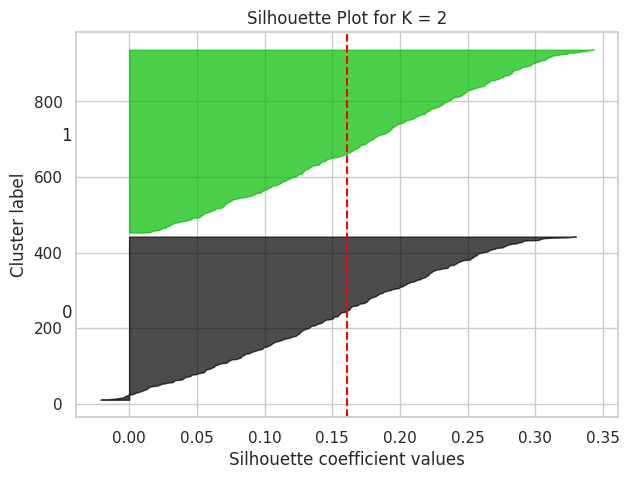

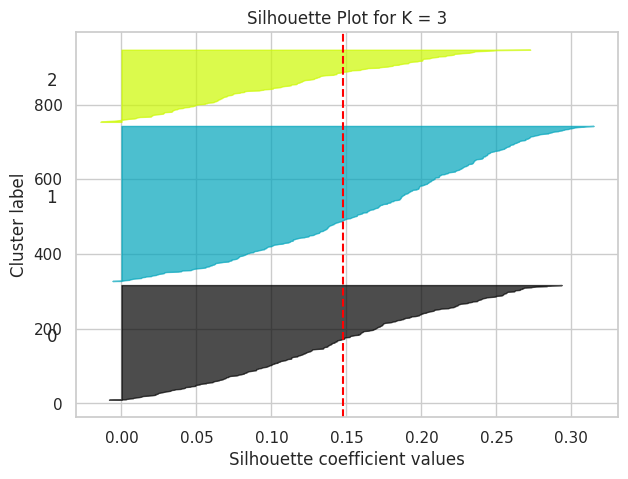

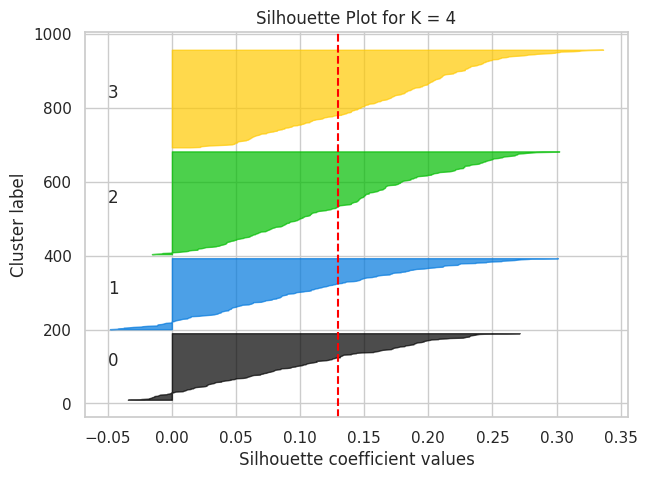

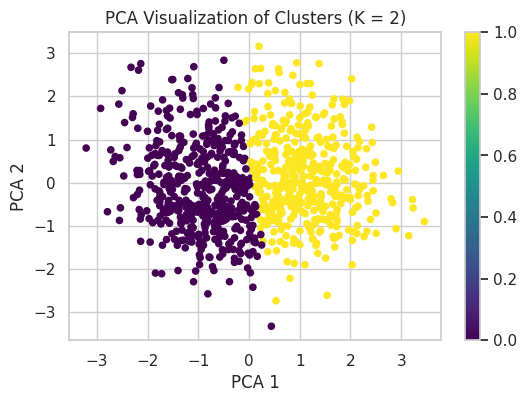

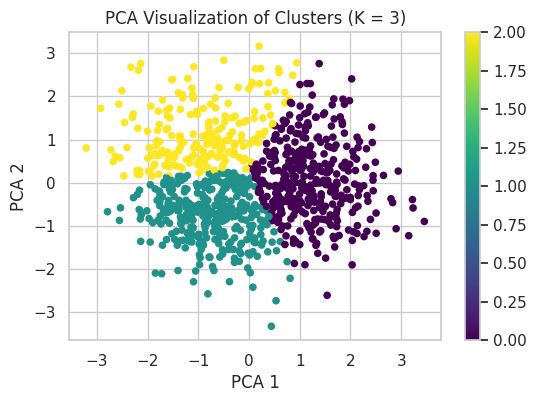

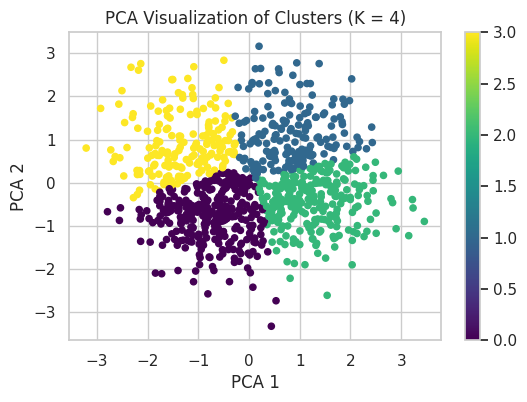

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.cm as cm

df = pd.read_csv("/content/sample_data/Preprocessed_data.csv")

if "HeartDisease" in df.columns:
    df = df.drop(columns=["HeartDisease"])

X = df.values

k_values = [2, 3, 4]

silhouette_results = []
wss_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    wss = kmeans.inertia_
    sil = silhouette_score(X, labels)
    wss_results.append(wss)
    silhouette_results.append(sil)
    print(f"K = {k} | WSS = {wss:.4f} | Silhouette = {sil:.4f}")

summary_df = pd.DataFrame({
    "K": k_values,
    "WSS": wss_results,
    "Silhouette Score": silhouette_results
})

display(summary_df.style.format({"WSS": "{:.4f}", "Silhouette Score": "{:.4f}"}))

def silhouette_plot(X, k):
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(7, 5)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_vals = silhouette_samples(X, labels)
    avg_silhouette = silhouette_score(X, labels)
    y_lower = 10

    for i in range(k):
        ith_cluster = silhouette_vals[labels == i]
        ith_cluster.sort()
        size_cluster = ith_cluster.shape[0]
        y_upper = y_lower + size_cluster
        color = cm.nipy_spectral(float(i) / k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=avg_silhouette, color="red", linestyle="--")
    ax1.set_title(f"Silhouette Plot for K = {k}")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    plt.show()

for k in k_values:
    silhouette_plot(X, k)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

def pca_plot(X_pca, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    plt.figure(figsize=(6, 4))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=20)
    plt.title(f"PCA Visualization of Clusters (K = {k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar(scatter)
    plt.show()

for k in k_values:
    pca_plot(X_pca, k)

# **7- Findings**

We started by selecting a heart disease dataset with the goal of identifying the factors most strongly associated with this condition and supporting more targeted preventive approaches. To ensure the reliability of our analysis, we carried out a thorough preprocessing phase that involved cleaning, organizing, and optimizing the data. A series of exploratory visualizations—including box plots, scatter plots, histogram, and bar graphs—helped us understand the underlying patterns and guided the decisions made throughout preprocessing. Based on these insights, we removed incomplete records, handled missing values, and eliminated extreme outliers that could negatively influence the results.

Once the data was cleaned, we prepared it for modeling by normalizing numerical features, selecting relevant attributes, and applying balancing techniques to address class distribution issues. With a refined and well-structured dataset, we advanced to the core data mining tasks: classification and clustering. For classification, we evaluated decision tree models using both the Gini index and Information Gain as splitting criteria. We also tested three different train–test partition ratios to determine which configuration produced the most effective model performance. Our key findings are summarized below.



**7.1.1 Information Gain**

In [35]:
data = {
    "Percentages": [
        "Accuracy", "Error Rate", "Sensitivity", "Specificity", "Precision"
    ],
    "70% training, 30% testing": [
        "0.7645", "0.2355", "0.7605", "0.7706", "0.8355"
    ],
    "60% training, 40% testing": [
        "0.7744", "0.2255", "0.7627", "0.7908", "0.8367"
    ],
    "80% training, 20% testing": [
        "0.8098", "0.1902", "0.8182", "0.7973", "0.8571"
    ]
}
g = pd.DataFrame(data)
g.style.set_properties(**{'text-align': 'center'})

,Percentages,"70% training, 30% testing","60% training, 40% testing","80% training, 20% testing"
0,Accuracy,0.7645,0.7744,0.8098
1,Error Rate,0.2355,0.2255,0.1902
2,Sensitivity,0.7605,0.7627,0.8182
3,Specificity,0.7706,0.7908,0.7973
4,Precision,0.8355,0.8367,0.8571



Based on the results presented for the models trained using different data splits, the following observations can be made:

• Accuracy:
Accuracy improves consistently as more training data is used, ranging from 76.45% to 80.98%. The 80–20 split achieves the highest accuracy (80.98%), followed by the 60–40 split (77.44%) and then the 70–30 split (76.45%). This indicates that providing the model with more training data results in improved performance.

• Error Rate:
The error rate ranges between 19.02% and 23.55%, which is the inverse of the accuracy results. The lowest error rate occurs in the 80–20 split (19.02%), showing that this configuration makes the fewest incorrect predictions. The 70–30 split has the highest error rate (23.55%).

• Sensitivity (True Positive Rate):
Sensitivity varies from 76.05% (70–30) to 81.82% (80–20). The 80–20 split provides the strongest ability to correctly detect heart disease cases (81.82%), followed by the 60–40 split (76.27%) and the 70–30 split (76.05%). Overall, the model's sensitivity improves significantly when trained on more data.

• Specificity (True Negative Rate):
Specificity ranges from 77.06% to 79.73%. The highest value comes from the 80–20 split (79.73%), followed by the 60–40 split (79.08%) and the 70–30 split (77.06%). This means that with more training data, the model becomes more accurate at identifying healthy cases and avoids false alarms more effectively.

• Precision:
Precision ranges from 83.55% to 85.71%, with the highest precision achieved in the 80–20 split (85.71%). The 60–40 split follows with 83.67%, and the 70–30 split with 83.55%. This shows that the model produces fewer false positives and maintains strong reliability when predicting heart disease, especially with the 80–20 split.

Conclusion

Overall, the Information Gain model demonstrates reliable and consistent performance across all three splits, with the 80–20 split delivering the best overall results by achieving the highest accuracy (80.98%), lowest error rate (19.02%), strongest sensitivity (81.82%), highest specificity (79.73%), and highest precision (85.71%). These results clearly show that the model becomes more effective and generalizes better when trained on a larger portion of the data. Therefore, the 80–20 train-test split is recommended as the optimal configuration for this classification task.

**7.1.2 GINI INDEX**

In [36]:
data = {
        "Percentages": [
        "Accuracy", "Error Rate", "Sensitivity", "Specificity", "Precision"
    ],

    "70% training, 30% testing": [
        " 0.7789", "0.2210", "0.7964", "0.7522", " 0.8312"
    ],
    "60% training, 40% testing	": [
        "0.7608", "0.2391", "0.7488", "0.7777", "0.8256"
    ],
    "	80% training, 20% testing": [
        "0.8043", "0.1956", "0.8000", "0.8108	","0.8627"
    ]
}
g = pd.DataFrame(data)
g.style.set_properties(**{'text-align': 'center'})

,Percentages,"70% training, 30% testing","60% training, 40% testing","80% training, 20% testing"
0,Accuracy,0.7789,0.7608,0.8043
1,Error Rate,0.2210,0.2391,0.1956
2,Sensitivity,0.7964,0.7488,0.8000
3,Specificity,0.7522,0.7777,0.8108
4,Precision,0.8312,0.8256,0.8627



Based on the results presented for the models trained using different data splits, the following observations can be made:

**• Accuracy:**

Accuracy values range from 76.08% to 80.43%, showing that the Gini model performs consistently across different splits. The 80–20 split achieves the highest accuracy (80.43%), followed by the 70–30 split (77.89%), while the 60–40 split records the lowest (76.08%). This indicates that the model learns more effectively when given more training data. Overall, the Gini index provides stable and reliable classification results.

**• Error Rate:**

The error rate lies between 19.56% and 23.91%, which matches the accuracy pattern. The lowest error rate occurs in the 80–20 split (19.56%), followed by 70–30 (22.10%) and 60–40 (23.91%). This confirms that the 80–20 configuration produces the fewest incorrect predictions. The consistent pattern across splits indicates that the model is stable and benefits from larger training sizes.

**• Sensitivity (True Positive Rate): **

Sensitivity ranges from 74.88% (60–40) to 80.00% (80–20). The 80–20 split achieves the highest sensitivity (80.00%), closely followed by the 70–30 split (79.64%), while the 60–40 split shows a notable drop to 74.88%. This demonstrates that the model detects more heart disease cases when trained with a larger portion of the data, with the 80–20 split being the most effective configuration.

**• Specificity (True Negative Rate):**

Specificity values range between 75.22% and 81.08%, with the highest value from the 80–20 split (81.08%). The 60–40 split follows with 77.77%, while the 70–30 split records 75.22%. This means the model is strongest at identifying non-heart-disease cases (true negatives) when trained on 80% of the data. Higher specificity also indicates fewer false positives, showing that the model is reliable when predicting healthy cases, especially under the 80–20 split.

**• Precision:**

Precision ranges from 82.56% to 86.27%, with the highest precision seen in the 80–20 split (86.27%). The 70–30 split follows with 83.12%, and the 60–40 split with 82.56%. This means most of the model's positive predictions (heart disease) were correct. The high precision across all splits indicates consistently strong predictive reliability, with the 80–20 split delivering the best performance.

**Conclusion**

The Gini Index model shows strong performance across all three splits, with the 80–20 split producing the best results across all metrics: highest accuracy (80.43%), lowest error rate (19.56%), highest sensitivity (80.00%), highest specificity (81.08%), and highest precision (86.27%). This makes it the strongest overall configuration. The model demonstrates excellent specificity and precision, indicating that it reliably identifies healthy patients and produces few false positives. Overall, the Gini-based decision tree provides strong and stable results across all configurations, with performance consistently improving as more training data is used.

**The best model between information gain and the Gini index**

In [29]:
import pandas as pd

data = {
    " ": [
        "Accuracy", "Error Rate", "Sensitivity","Specificity","Precision"
    ],
    "Information Gain": [
        "0.8098",  "0.1902","0.8182","0.7973","0.8571"
    ],
    "Gini Index": [
        "0.8043", "0.1956","0.8000","0.8108","0.8627"
    ]
}

g = pd.DataFrame(data)
g.style.set_properties(**{'text-align': 'center'})


,,Information Gain,Gini Index
0,Accuracy,0.8098,0.8043
1,Error Rate,0.1902,0.1956
2,Sensitivity,0.8182,0.8000
3,Specificity,0.7973,0.8108
4,Precision,0.8571,0.8627


**Accuracy and Error Rate**


Information Gain reached an accuracy of 80.98%, which is slightly higher than the Gini Index’s 80.43%. Both methods perform similarly, but Information Gain is a bit more accurate overall. It also has a lower error rate—19.02% compared to 19.56% for Gini. This means Information Gain makes fewer mistakes, making it slightly more dependable for predicting heart-disease cases.

**Sensitivity and Specificity:**

With the 80/20 split, Information Gain shows higher sensitivity at 81.82%, compared to the Gini Index at 80.00%, meaning it is slightly better at correctly identifying positive heart-disease cases. On the other hand, the Gini Index achieves higher specificity at 81.08%, while Information Gain records 79.73%, showing that Gini is more accurate at recognizing true negatives. Overall, Information Gain is a bit stronger at catching positive cases, while Gini performs slightly better at ruling out negative ones.

**Precision**

The Gini Index achieves a precision of 86.27%, slightly higher than Information Gain’s 85.71%. This small advantage means the Gini-based model produces fewer false positives, making it a bit more reliable when predicting true positive cases.

**Conclusion**

Both splitting criteria perform well, but each excels in different areas. *Information Gain* achieves the highest accuracy (80.98%), lowest error rate (19.02%), and strongest sensitivity (81.82%), making it the better option when correctly identifying positive cases is the priority. In contrast, the *Gini Index* offers higher specificity (81.08%) and precision (86.27%), making it more dependable for avoiding false positives and correctly identifying negative cases. The best choice ultimately depends on the goal: choose *Information Gain* when maximizing true-positive detection is most important, and choose *Gini* when reducing misclassified negatives matters more.




Below is the decision tree for the 80 / 20 split (Information Gain):

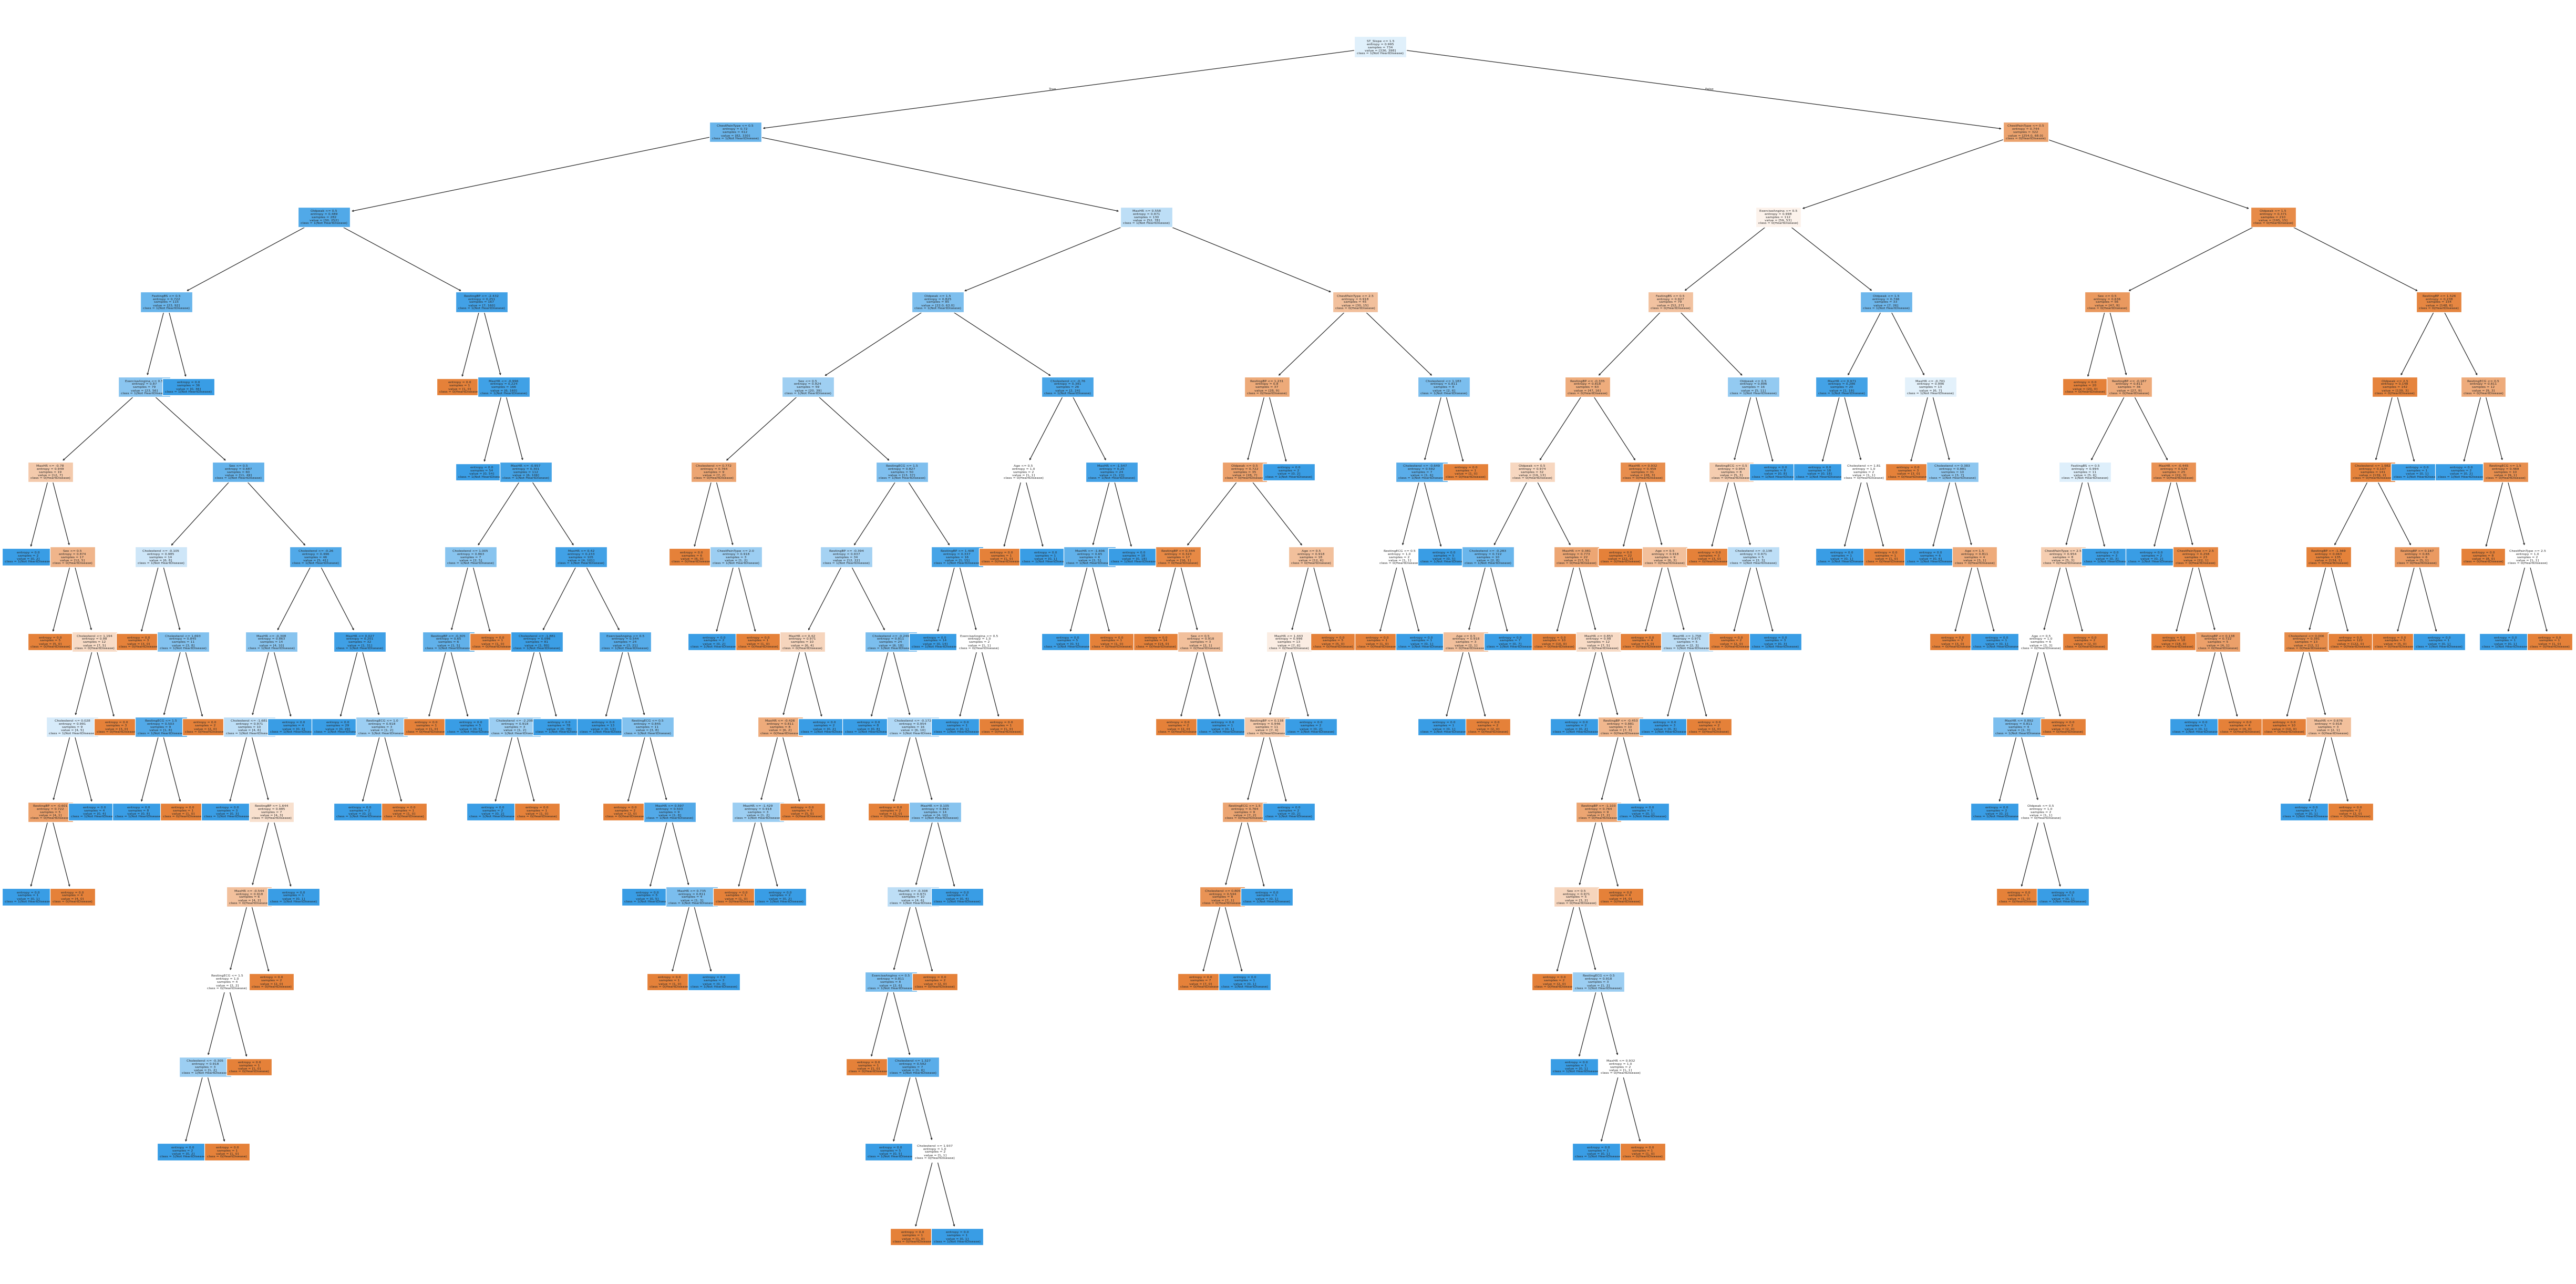

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


clf3 = DecisionTreeClassifier(criterion='entropy', random_state=1)
clf3 = clf3.fit(X_train, y_train)


y_pred = clf3.predict(X_test)


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm3 = confusion_matrix(y_test, y_pred)


from sklearn.metrics import ConfusionMatrixDisplay

cm3 = confusion_matrix(y_test, y_pred)

class_labels = {0: '0(HeartDisease)', 1: '1(Not HeartDisease)'}




import matplotlib.pyplot as plt
from sklearn import tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(70, 35), dpi=90)

# Define feature names for plotting the tree
fn = [col for col in df.columns if col != 'HeartDisease']


class_labels = {0: '0(HeartDisease)', 1: '1(Not HeartDisease)'}

tree.plot_tree(clf3,
               feature_names=fn,
               class_names=[class_labels[0], class_labels[1]],
               filled=True,
               fontsize=5,
               ax=axes


               )

plt.show()

The heart-disease decision tree makes predictions by using the most informative patient features to split the data. It starts with the attribute that provides the greatest separation between classes and then continues branching using the remaining predictors in order of decreasing importance. The model considers factors such as Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, MaxHR, ExerciseAngina, Oldpeak, and ST_Slope. Each path eventually leads to a leaf node that assigns a class label (0 for Heart Disease, 1 for No Heart Disease) based on the combination of feature values. This hierarchical structure shows how different clinical variables interact to distinguish between patients with and without heart disease, making the model’s decision logic transparent and easy to interpret.



**7.2 Clustering**

We applied multiple clustering evaluation techniques to determine the most appropriate number of clusters (K) for our dataset. After calculating the average silhouette score across different K values, we obtained the following insights:

In [32]:
import pandas as pd

data = {
    " ": ["WSS", "Silhouette"],
    "k=2": ["7257.779", "0.19879718749735742"],
    "k=3": ["6576.07", "0.1858655312451745"],
    "k=4": ["5968.30 ", "0.17561137851742672"]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)

g = pd.DataFrame(data)
g.style.set_properties(**{'text-align': 'center'})

,,k=2,k=3,k=4
0,WSS,7257.779,6576.07,5968.30
1,Silhouette,0.19879718749735742,0.1858655312451745,0.17561137851742672


The highest silhouette score is achieved at k = 2, and the corresponding WSS value remains appropriately large. The silhouette plot for two clusters also displays the most distinct and well-formed groups. Therefore, k = 2 is the most suitable number of clusters for this dataset.

**The corresponding plot chart**

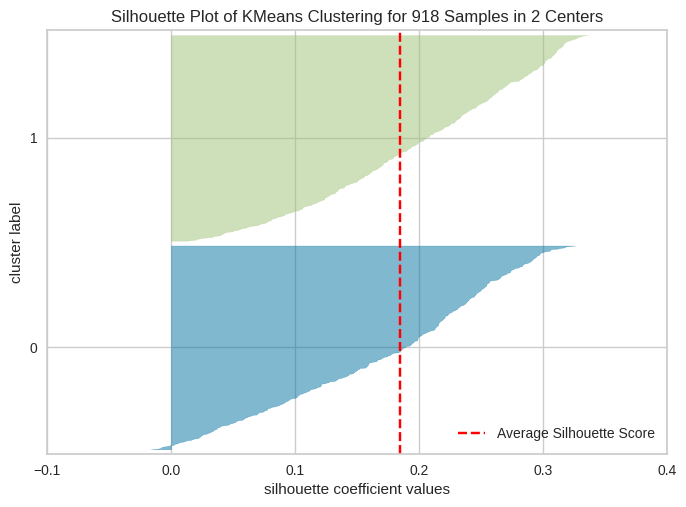

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 918 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [34]:
!pip install yellowbrick
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd  # Import pandas

scaled_data = pd.read_csv("/content/sample_data/Preprocessed_data.csv")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=2, n_init='auto')

# Set the color theme for the visualizer using a valid colormap
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')

# Fit the visualizer on the scaled data
visualizer.fit(scaled_data)

# Show the silhouette plot
visualizer.show()

The K-means silhouette plot shows that most points have positive scores, indicating that they fit well within their assigned clusters and are clearly separated from others. This reflects strong overall clustering performance. However, positive values alone do not imply a perfect partition—points located near cluster boundaries may still produce scores close to zero or even negative, indicating areas of overlap or uncertainty between clusters.

# **Finally** 11


While clustering helped reveal natural groupings within the patient data, its insights are limited because the dataset already includes labels indicating heart-disease status. Supervised classification models make fuller use of this information, allowing them to produce far more accurate and clinically meaningful predictions. By learning directly from known outcomes, these models more effectively identify the key factors associated with heart disease and provide stronger support for targeted prevention and early intervention strategies.

**Discussion Based on the Selected Research Paper**

The findings of this study align closely with the methodologies and insights presented in the selected research paper “Cardiac Failure Forecasting Based on Clinical Data Using Machine Learning Metamodel”. The paper highlights the importance of comparing different machine-learning techniques to identify the most effective approach for predicting heart-related outcomes. Similarly, our analysis evaluated multiple decision-tree splitting criteria and clustering configurations to identify which methods provide the strongest predictive performance.

Decision Tree Classification Analysis

The research paper emphasizes that classification models often differ in their strengths depending on the performance metric being measured. This pattern is consistent with our results.
	•	Information Gain in our study demonstrated the highest accuracy (80.98%), lowest error rate (19.02%), and strongest sensitivity (81.82%). This closely reflects the paper’s observation that some models are more effective at identifying true positive medical cases, especially when early detection is critical.
	•	On the other hand, Gini Index achieved higher specificity (81.08%) and precision (86.27%), which matches the paper’s conclusion that certain models are better suited for minimizing false positives and improving reliability in negative-class identification.

Just as the research article stresses the importance of selecting a model based on the specific clinical or analytical goal, our findings show that the optimal splitting criterion depends on whether the priority is detecting as many positive cases as possible (Information Gain) or reducing misclassified negatives (Gini Index).

Clustering Analysis

The paper also highlights the value of unsupervised techniques in understanding patient groupings and underlying data structure. In line with this, our clustering evaluation using K-means revealed the following:
	•	The highest silhouette score occurred at k = 2, indicating that two clusters best represent the natural structure of the dataset.
	•	The silhouette plot for k = 2 showed clear and well-formed clusters, mirroring the paper’s approach of identifying meaningful patient segments based on shared clinical characteristics.

However, consistent with the paper’s caution about cluster interpretation, not all points achieved high silhouette values. Some borderline points had scores near zero or negative, suggesting overlap — a limitation also discussed in the research article.



# **8- References**



[1] B. Siontis, V. M. Noseworthy, P. Attia, and Y. V. Murad, "Artificial Intelligence in Heart Disease Diagnosis," *Mayo Clinic Proceedings*, vol. 94, no. 10, pp. 1101–1111, Oct. 2019. [Online]. Available: https://pubmed.ncbi.nlm.nih.gov/31592122/

[2] F. Soriano, "Heart Failure Prediction Dataset," *Kaggle*, 2021. [Online]. Available: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction